In [ ]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd
from sklearn.feature_selection import RFE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from skopt import BayesSearchCV
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from skopt.space import Real, Integer
import mlflow
from sklearn.model_selection import GridSearchCV

# useful methods

below are some useful methods that I am going to be using later on.


## constant remover

simply removes columns that only have 1 unique value

In [ ]:

# === 1. Drop constant columns ===
class ConstantColumnRemover(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.cols_to_keep = [col for col in X.columns if X[col].nunique() > 1]
        # mlflow.log_param("ConstantColumnRemover_cols_kept", len(self.cols_to_keep))
        return self
    def transform(self, X):
        return X[self.cols_to_keep]
    

## NA filler(cleaning)

fill nan/null values of the dataframe. the user can specify how it wants categorical and numerical columns to be handled. by default, categorical values become "missing" and numericals become 999.

In [ ]:
# === 2. NAFiller ===
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer

class NAFiller(BaseEstimator, TransformerMixin):
    def __init__(self, num_strategy='mean', num_fill_value=999,
                 cat_strategy='constant', cat_fill_value='Missing'):
        self.num_strategy = num_strategy
        self.num_fill_value = num_fill_value
        self.cat_strategy = cat_strategy
        self.cat_fill_value = cat_fill_value

    def fit(self, X, y=None):
        self.num_cols = X.select_dtypes(include=['number']).columns.tolist()
        self.cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

        self.num_imputer = SimpleImputer(strategy=self.num_strategy, fill_value=self.num_fill_value)
        if self.num_cols:
            self.num_imputer.fit(X[self.num_cols])

        self.cat_imputer = SimpleImputer(strategy=self.cat_strategy, fill_value=self.cat_fill_value)
        if self.cat_cols:
            self.cat_imputer.fit(X[self.cat_cols])

        return self

    def transform(self, X):
        X = X.copy()
        if self.num_cols:
            X[self.num_cols] = self.num_imputer.transform(X[self.num_cols])
        if self.cat_cols:
            X[self.cat_cols] = self.cat_imputer.transform(X[self.cat_cols])
        return X
    

## NAFillerSearch(cleaning)

a better version of the method described above. used for optimising, i can choose 4 different fill methods with the number 0,1,2,3. 0 is fill with 0, 1 is fil with 99, 2 is fill with mean and 3 is fill with most common.

In [ ]:
class NAFillerSearch(BaseEstimator, TransformerMixin):
    def __init__(self, strategy=0, cat_strategy='constant', cat_fill_value='Missing'):
        self.strategy = strategy
        self.cat_strategy = cat_strategy
        self.cat_fill_value = cat_fill_value

    def fit(self, X, y=None):
        if self.strategy == 1:
            num_strategy = 'constant'
            num_fill_value = 99
        elif self.strategy == 2:
            num_strategy = 'mean'
            num_fill_value = 0
        elif self.strategy == 3:
            num_strategy = 'most_frequent'
            num_fill_value = 0
        else:
            num_strategy = 'constant'
            num_fill_value = 0

        # mlflow.log_param("NAFillerSearch_num_strategy", num_strategy)
        # mlflow.log_param("NAFillerSearch_cat_strategy", self.cat_strategy)

        self.num_cols = X.select_dtypes(include=['number']).columns.tolist()
        self.cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

        self.num_imputer = SimpleImputer(strategy=num_strategy, fill_value=num_fill_value)
        if self.num_cols:
            self.num_imputer.fit(X[self.num_cols])

        self.cat_imputer = SimpleImputer(strategy=self.cat_strategy, fill_value=self.cat_fill_value)
        if self.cat_cols:
            self.cat_imputer.fit(X[self.cat_cols])

        return self

    def transform(self, X):
        X = X.copy()
        if self.num_cols:
            X[self.num_cols] = self.num_imputer.transform(X[self.num_cols])
        if self.cat_cols:
            X[self.cat_cols] = self.cat_imputer.transform(X[self.cat_cols])
        return X

## encoder(cleaning)

this method turns categorical columns into numerical. it takes a threshold, below is OHE and above - WOE. can be used with bayesian search to find the optimal value of the threshold.

In [ ]:

# === 3. Encoder ===

class Encoder(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=3):
        self.threshold = threshold
        self.ohe_cols = []
        self.woe_cols = []
        self.woe_maps = {}
        self.ohe_df_columns = []

    def fit(self, X, y):
        # mlflow.log_param("Encoder_threshold", self.threshold)
        X = X.copy()
        y = pd.Series(y).reset_index(drop=True)
        
        for col in X.select_dtypes(include=['object', 'category']):
            unique_vals = X[col].nunique(dropna=True)
            if unique_vals < self.threshold:
                self.ohe_cols.append(col)
            else:
                self.woe_cols.append(col)
                self.woe_maps[col] = self._compute_woe(X[col], y)

        if self.ohe_cols:
            ohe_df = pd.get_dummies(X[self.ohe_cols], dummy_na=True)
            self.ohe_df_columns = ohe_df.columns.tolist()
        # print("finished fitting Encoder")
        # mlflow.log_param("Encoder_ohe_cols", len(self.ohe_cols))
        # mlflow.log_param("Encoder_woe_cols", len(self.woe_cols))
        
        return self

    def transform(self, X):
        X = X.copy()
        output = X.drop(columns=self.ohe_cols + self.woe_cols, errors='ignore')

        # Apply WOE encoding
        for col in self.woe_cols:
            woe_map = self.woe_maps[col]
            X[col] = X[col].map(woe_map).fillna(0)  # fill unknown categories with 0
            output[col] = X[col]

        # Apply One-Hot Encoding
        if self.ohe_cols:
            ohe_df = pd.get_dummies(X[self.ohe_cols], dummy_na=True)
            # Align with training columns to ensure consistency
            ohe_df = ohe_df.reindex(columns=self.ohe_df_columns, fill_value=0)
            output = pd.concat([output, ohe_df], axis=1)
        # print("finished transforming Encoder")
        return output

    def _compute_woe(self, feature_col, target_col):
        df = pd.DataFrame({'feature': feature_col, 'target': target_col})
        df = df.dropna(subset=['feature'])  # Drop missing for WOE mapping
        grouped = df.groupby('feature')

        # total good and bad
        total_good = (df['target'] == 0).sum()
        total_bad = (df['target'] == 1).sum()

        woe_map = {}
        for val, group in grouped:
            good = (group['target'] == 0).sum()
            bad = (group['target'] == 1).sum()

            # Avoid division by zero
            epsilon = 1e-6
            good_ratio = good / total_good if total_good else epsilon
            bad_ratio = bad / total_bad if total_bad else epsilon
            woe = np.log((good_ratio + epsilon) / (bad_ratio + epsilon))

            woe_map[val] = woe

        return woe_map



## simple feature engineering

this class makes new columns based on old ones. In this kaggle task it is very difficult to do so, as the columns are hidden and unintuitive, but there are some manipulations we could do, such as dividing the date into weeks and months. I also wanted to create columns such as the average transaction per user, but refrained from doing so as i believed I did not have enough data to do so, but it is a possibility.

In [ ]:

# === 4. Feature Engineering ===
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, origin_date=pd.Timestamp('2017-11-30')):
        self.origin_date = origin_date

    def fit(self, X, y=None):
        # print("finished fitting FeatureEngineer")
        return self

    def transform(self, X):
        X = X.copy()
        if 'TransactionDT' in X.columns:
            X['datetime'] = self.origin_date + pd.to_timedelta(X['TransactionDT'], unit='s')
            X['weekday'] = X['datetime'].dt.weekday
            X['month'] = X['datetime'].dt.month
            X.drop(columns=['datetime'], inplace=True)

        if 'TransactionAmt' in X.columns and 'card1' in X.columns:
            X['card1_avg_amt'] = X.groupby('card1')['TransactionAmt'].transform('mean')
        # print('finished transforming FeatureEngineer')
        return X

#  RFE,  correlationFilter (feature selection)

I am using those two to select my features. i did not make a custom RFE class of course). everythin is neatly packaged in my pipeline.

In [ ]:

# === 5. Correlation Filter ===
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8):
        self.threshold = threshold
        self.cols_to_keep = []

    def fit(self, X, y=None):
        X = X.copy()
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        cols_to_drop = set()
        for col in upper.columns:
            high_corr = upper[col][upper[col] > self.threshold]
            for row_col in high_corr.index:
                if row_col in cols_to_drop or col in cols_to_drop:
                    continue
                if y is not None:
                    col_corr = abs(np.corrcoef(X[col], y)[0, 1])
                    row_col_corr = abs(np.corrcoef(X[row_col], y)[0, 1])
                    drop_col = col if col_corr < row_col_corr else row_col
                else:
                    drop_col = row_col  # fallback
                cols_to_drop.add(drop_col)
        
        self.cols_to_keep = [col for col in X.columns if col not in cols_to_drop]
        # mlflow.log_param("correlation_amount_cols_dropped", len(cols_to_drop))
        # mlflow.log_param("correlation_amount_cols_kept", len(self.cols_to_keep))

        return self

    def transform(self, X):
        return X[self.cols_to_keep]

## scalers

just scalers. the reason i made it separately is that mine ignores NAN values. when I inputted 9999 into the NAfiller, it the total number used to calculate mean and deviation got too big and it would give me errors, therefore i thought about reducing everything first and then using 99.

In [1]:

# === 6. scaler ===

class Scaler(BaseEstimator, TransformerMixin):
    def __init__(self, scaler=None):
        self.scaler = scaler if scaler is not None else StandardScaler()
        self.columns = []

    def fit(self, X, y=None):
        X = X.copy()
        self.columns = X.select_dtypes(include=[np.number]).columns.tolist()
        self.scaler.fit(X[self.columns])
        # print("finished fitting Scaler")
        return self

    def transform(self, X):
        X = X.copy()
        X[self.columns] = self.scaler.transform(X[self.columns])
        # print("finished transforming Scaler")
        return X




class GaussianNormalizer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.means_ = {}
        self.stds_ = {}
        self.columns = []

    def fit(self, X, y=None):
        X = X.copy()
        self.columns = X.select_dtypes(include=[np.number]).columns.tolist()
        for col in self.columns:
            col_data = X[col].dropna()
            self.means_[col] = col_data.mean()
            self.stds_[col] = col_data.std(ddof=0)  # population std
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            mean = self.means_[col]
            std = self.stds_[col]
            if std == 0 or np.isnan(std):
                X[col] = 0  # handle constant or all-NaN columns
            else:
                X[col] = (X[col] - mean) / std
        return X


In [2]:
import pandas as pd
train_identity  = pd.read_csv('ieee-fraud-detection/train_identity.csv')
train_transaction  = pd.read_csv('ieee-fraud-detection/train_transaction.csv')
test_identity = pd.read_csv('ieee-fraud-detection/test_identity.csv')
test_transaction = pd.read_csv('ieee-fraud-detection/test_transaction.csv')
# Normalize column names (replace '-' with '_')
train_identity.columns = train_identity.columns.str.replace('-', '_')
test_identity.columns = test_identity.columns.str.replace('-', '_')
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

In [3]:
# Usage
X = train.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y = train['isFraud']
X_test = test.drop(columns=['TransactionID'], errors='ignore')

In [22]:


# Define pipeline
pipeline = ImbPipeline([
    ('na_filler', NAFiller()),
    ('remove_constants', ConstantColumnRemover()),
    ('feature_engineering', FeatureEngineer()),
    ('categorical_encoding', Encoder()),  # threshold is tuned
    ('undersampler', RandomUnderSampler(random_state=42)),  # strategy is tuned
    ('rfe', RFE(estimator=XGBClassifier(eval_metric='logloss'), step = 0.15)),  # n_features is tuned
    ('classifier', XGBClassifier(eval_metric='logloss'))
])

# Define search space
search_spaces = {
    'categorical_encoding__threshold': Integer(2, 10),
    'undersampler__sampling_strategy': Real(0.05, 0.5, prior='uniform'),
    'rfe__n_features_to_select': Integer(20, 100),  # adjust based on your data

    # XGBoost hyperparams
    'classifier__n_estimators': Integer(50, 300),
    'classifier__max_depth': Integer(3, 10),
    'classifier__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'classifier__subsample': Real(0.5, 1.0, prior='uniform'),
    'classifier__colsample_bytree': Real(0.5, 1.0, prior='uniform'),
    'classifier__gamma': Real(0, 5, prior='uniform'),
    'classifier__reg_alpha': Real(0, 5, prior='uniform'),
    'classifier__reg_lambda': Real(0, 5, prior='uniform')
}


# Define cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# BayesSearchCV
opt = BayesSearchCV(
    estimator=pipeline,
    search_spaces=search_spaces,
    scoring='f1',
    cv=cv,
    n_iter=12,  # increase for better results
    n_jobs=-1,
    verbose=2,
    random_state=42,
    n_points=2
)

# Fit to training data
opt.fit(X, y)

# Results
print("Best f1:", opt.best_score_)
print("Best parameters:")
for param, val in opt.best_params_.items():
    print(f"  {param}: {val}")

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best f1: 0.6830927244643826
Best parameters:
  categorical_encoding__threshold: 5
  classifier__colsample_bytree: 0.5
  classifier__gamma: 0.512249297709735
  classifier__learning_rate: 0.29999999999999993
  classifier__max_depth: 8
  classifier__n_estimators: 300
  classifier__reg_alpha: 5.0
  classifier__reg_lambda: 0.0
  classifier__subsample: 0.8752679984645589
  rfe__n_features_to_select: 100
  undersampler__sampling_strategy: 0.05


In [4]:
from sklearn.feature_selection import RFE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from skopt import BayesSearchCV
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from skopt.space import Real, Integer, Categorical

# Define pipeline
pipeline = ImbPipeline([
    ('na_filler', NAFiller()),
    ('remove_constants', ConstantColumnRemover()),
    ('feature_engineering', FeatureEngineer()),
    ('categorical_encoding', Encoder(threshold=5)),  # threshold is tuned
    ('correlation_filter', CorrelationFilter()),
    ('undersampler', RandomUnderSampler(random_state=42)),  # strategy is tuned
    ('rfe', RFE(estimator=XGBClassifier(eval_metric='logloss', 
                                        max_depth=8, reg_alpha=5, 
                                        reg_lambda=1,
                                        colsample_bytree=0.5), step = 0.05)),  # n_features is tuned
    ('classifier', XGBClassifier(eval_metric='logloss', 
                                        max_depth=8, reg_alpha=5, 
                                        reg_lambda=1,
                                        colsample_bytree=0.5))
])

# Define search space
search_spaces = {
    # 'na_filler__num_strategy': Categorical(['constant', 'mean', 'median']),
    # 'na_filler__num_fill_value': Categorical([0, 999]),
    'undersampler__sampling_strategy': Real(0.05, 0.5, prior='uniform'),
    'rfe__n_features_to_select': Integer(60, 120),  # adjust based on your data
    'rfe__step': Real(0.05, 0.15, prior='uniform'),
    'correlation_filter__threshold': Real(0.6, 0.98, prior='uniform'),
    # XGBoost hyperparams
    'classifier__n_estimators': Integer(40, 200),
    # 'classifier__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'classifier__subsample': Real(0.5, 1.0, prior='uniform'),
    'classifier__gamma': Real(0, 5, prior='uniform'),
}


# Define cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# BayesSearchCV
opt = BayesSearchCV(
    estimator=pipeline,
    search_spaces=search_spaces,
    scoring='f1',
    cv=cv,
    n_iter=24,  # increase for better results
    n_jobs=-1,
    verbose=2,
    random_state=42,
    n_points=2
)

# Fit to training data
opt.fit(X, y)

# Results
print("Best f1:", opt.best_score_)
print("Best parameters:")
for param, val in opt.best_params_.items():
    print(f"  {param}: {val}")

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best f1: 0.6993082580060168
Best parameters:
  classifier__gamma: 0.0
  classifier__n_estimators: 200
  classifier__subsample: 1.0
  correlation_filter__threshold: 0.98
  rfe__n_features_to_select: 120
  rfe__step: 0.15
  undersampler__sampling_strategy: 0.05


CV f1 scores: [0.54770017 0.57013707 0.55428167 0.56859931 0.55162496]
Mean f1: 0.5584686363898278
Test ROC AUC: 0.9531657028996687
Test f1: 0.6899212170605814
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    569877
           1       0.79      0.61      0.69     20663

    accuracy                           0.98    590540
   macro avg       0.89      0.80      0.84    590540
weighted avg       0.98      0.98      0.98    590540

Confusion Matrix:
[[566428   3449]
 [  7965  12698]]


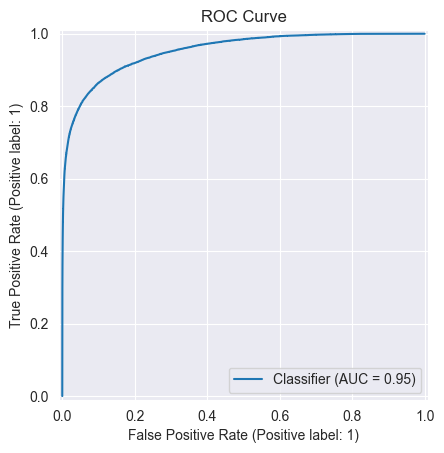

In [9]:


pipeline = ImbPipeline([
    ("GaussianNormalizer", GaussianNormalizer()),
    ('na_filler', NAFiller(num_strategy='most_frequent')),
    ('remove_constants', ConstantColumnRemover()),
    ('feature_engineering', FeatureEngineer()),
    ('categorical_encoding', Encoder(threshold=5)),  # threshold is tuned
    ("GaussianNormalizer2", GaussianNormalizer()),
    ('correlation_filter', CorrelationFilter(threshold=0.95)),
    ('undersampler', RandomUnderSampler(random_state=42,sampling_strategy=0.3)),  # strategy is tuned
    ('rfe', RFE(estimator=XGBClassifier(eval_metric='logloss', 
                                        max_depth=8, reg_alpha=4, 
                                        reg_lambda=1,
                                        colsample_bytree=0.5,
                                        n_estimators=50), 
                step = 0.1,
                n_features_to_select=120)),  # n_features is tuned
    ('rfe2', RFE(estimator=XGBClassifier(eval_metric='logloss', 
                                        max_depth=8, reg_alpha=4, 
                                        reg_lambda=1,
                                        colsample_bytree=0.5,
                                        n_estimators=50), 
                step = 5,
                n_features_to_select=30)),  # n_features is tuned
    ('classifier', XGBClassifier(eval_metric='logloss', 
                                        max_depth=8, reg_alpha=4,
                                        reg_lambda=1,
                                        colsample_bytree=0.5,
                                 n_estimators=100))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, scoring='f1', cv=cv)
print("CV f1 scores:", cv_scores)
print("Mean f1:", cv_scores.mean())

pipeline.fit(X, y)
y_pred = pipeline.predict(X)
y_pred_proba = pipeline.predict_proba(X)[:, 1]

roc_auc = roc_auc_score(y, y_pred_proba)
f1 = f1_score(y, y_pred, average='binary')
print("Test ROC AUC:", roc_auc)
print("Test f1:", f1)

print("Classification Report:")
print(classification_report(y, y_pred))

conf_matrix = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

RocCurveDisplay.from_predictions(y, y_pred_proba)
plt.title("ROC Curve")
plt.show()

In [5]:
display(X)

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,86400,68.50,W,13926,NaN,150.0,discover,142.0,credit,315.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,86469,59.00,W,4663,490.0,150.0,visa,166.0,debit,330.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,15811047,49.00,W,6550,NaN,150.0,visa,226.0,debit,272.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,debit,204.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,debit,231.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,debit,387.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
import dagshub
import mlflow
import mlflow.sklearn
# Initialize DagsHub logging
dagshub.init(repo_owner='arazm21', repo_name='ML-homework_2', mlflow=True)

Accessing as arazm21

Initialized MLflow to track repo "arazm21/ML-homework_2"

Repository arazm21/ML-homework_2 initialized!

In [ ]:


from skopt.callbacks import VerboseCallback
import tempfile
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import seaborn as sns

pipeline = ImbPipeline([
    # ("GaussianNormalizer", GaussianNormalizer()),
    ('undersampler', RandomUnderSampler(sampling_strategy=0.3)),  # strategy is tuned

    ('na_filler', NAFillerSearch(strategy=3)),
    ('remove_constants', ConstantColumnRemover()),
    ('feature_engineering', FeatureEngineer()),
    ('categorical_encoding', Encoder(threshold=5)),  # threshold is tuned
    ("GaussianNormalizer2", GaussianNormalizer()),
    ('correlation_filter', CorrelationFilter(threshold=0.8)),
    # ('undersampler', RandomUnderSampler(random_state=42,sampling_strategy=0.1)),  # strategy is tuned
    ('rfe', RFE(estimator=XGBClassifier(eval_metric='logloss', 
                                        max_depth=6, reg_alpha=2,
                                        subsample=0.9,
                                        reg_lambda=3,
                                        min_child_weight=2,
                                        gamma=0.01,
                                        colsample_bytree=0.5,
                                 n_estimators=400,
                                 learning_rate=0.1,n_jobs=-1,), 
                step = 10,
                n_features_to_select=200)),  # n_features is tuned
    ('rfe2', RFE(estimator=XGBClassifier(eval_metric='logloss', 
                                        max_depth=6, reg_alpha=2,
                                        subsample=0.9,
                                        reg_lambda=3,
                                        min_child_weight=2,
                                        gamma=0.01,
                                        colsample_bytree=0.5,
                                 n_estimators=400,
                                 learning_rate=0.1,
                                         n_jobs=-1,), 
                step = 5,
                n_features_to_select=120)),  # n_features is tuned
    ('classifier', XGBClassifier(eval_metric='logloss', 
                                        max_depth=6, reg_alpha=2,
                                        subsample=0.9,
                                        reg_lambda=3,
                                        min_child_weight=2,
                                        gamma=3,
                                        colsample_bytree=0.5,
                                 n_estimators=2000,
                                 learning_rate=0.1,
                                 n_jobs=-1,))
])
search_spaces = {
    'undersampler__sampling_strategy': Real(0.05, 0.5, prior='uniform'),
    'rfe2__n_features_to_select': Integer(50, 150),  # adjust based on your data
    

    # XGBoost hyperparams
    'classifier__n_estimators': Integer(1000, 2000),
    'classifier__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'classifier__subsample': Real(0.5, 1.0, prior='uniform'),
    'classifier__colsample_bytree': Real(0.5, 1.0, prior='uniform'),
    'classifier__gamma': Real(0, 5, prior='uniform'),
    'classifier__reg_alpha': Real(0, 5, prior='uniform'),
    'classifier__reg_lambda': Real(0, 5, prior='uniform')
}

# Define a callback to log each trial
# def mlflow_callback(res):
#     """Logs each BayesSearchCV result to MLflow."""
#     with mlflow.start_run(nested=True):
#         iteration = len(res.x_iters) - 1
#         params = res.x
#         score = res.func_vals[-1]
# 
#         for name, val in zip(opt.search_spaces_.keys(), params):
#             mlflow.log_param(name, val)
#         mlflow.log_metric("f1_score_cv", -score)  # Negated since BayesSearchCV minimizes
# 
#         mlflow.set_tag("iteration", iteration)

# Train/test split
X_train, X_eval, y_train, y_eval = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
with mlflow.start_run(run_name="Bayesian Optimization - Clean Pipeline Logging_2") as run:
    mlflow.set_tag("model_type", "XGBoost + Custom Pipeline")
    
    # To avoid logging from internal XGB calls, disable auto-logging temporarily
    mlflow.sklearn.autolog(disable=True)
    
    search = BayesSearchCV(
        pipeline,
        search_spaces,
        n_iter=20,
        cv=3,
        n_jobs=-1,
        scoring='f1',
        verbose=2,
        random_state=42,
        n_points=2
    )
    
    search.fit(X_train, y_train)

2025/05/01 06:28:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Best ROC AUC: 0.9693305584490086
Best parameters found:
 OrderedDict({'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0.0, 'classifier__learning_rate': 0.10609025573645334, 'classifier__n_estimators': 2000, 'classifier__reg_alpha': 0.0, 'classifier__reg_lambda': 0.0, 'classifier__subsample': 1.0, 'rfe2__n_features_to_select': 131, 'undersampler__sampling_strategy': 0.05})
🏃 View run Bayesian Optimization - Clean Pipeline Logging_3 at: https://dagshub.com/arazm21/ML-homework_2.mlflow/#/experiments/0/runs/e95b7914cfb043eabafede6c67042e20
🧪 View experiment at: https://dagshub.com/arazm21/ML-homework_2.mlflow/#/experiments/0


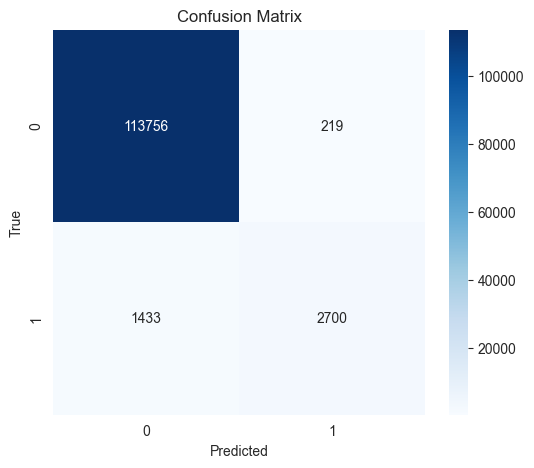

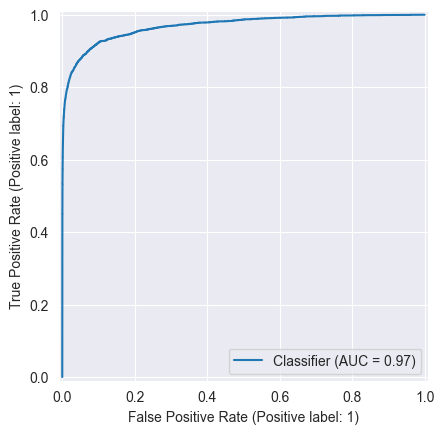

In [6]:
with mlflow.start_run(run_name="Bayesian Optimization - Clean Pipeline Logging_3") as run:
    mlflow.set_tag("model_type", "XGBoost + Custom Pipeline")
    # Manually log best params and model
    mlflow.log_params(search.best_params_)
    mlflow.sklearn.log_model(
    opt.best_estimator_,
    "best_pipeline_model",
    input_example=X_train.iloc[:5],  # A small sample of inputs
    signature=mlflow.models.infer_signature(X_train, opt.predict(X_train))
    )

    # Predict and evaluate
    y_pred = search.predict(X_eval)
    y_proba = search.predict_proba(X_eval)[:, 1]

    # Metrics
    roc_auc = roc_auc_score(y_eval, y_proba)
    mlflow.log_metric("test_roc_auc", roc_auc)
    f1 = f1_score(y_eval, y_pred)
    mlflow.log_metric("test_f1", f1)
    
    # Classification report
    report = classification_report(y_eval, y_pred, output_dict=True)
    for label, scores in report.items():
        if isinstance(scores, dict):
            for metric, value in scores.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    # Confusion Matrix
    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    cm_path = "confusion_matrix.png"
    plt.savefig(cm_path)
    mlflow.log_artifact(cm_path)

    # ROC Curve
    from sklearn.metrics import RocCurveDisplay
    RocCurveDisplay.from_predictions(y_eval, y_proba)
    roc_path = "roc_curve.png"
    plt.savefig(roc_path)
    mlflow.log_artifact(roc_path)

    # Re-enable autologging (optional)
    mlflow.sklearn.autolog(disable=False)

    print("Best ROC AUC:", roc_auc)
    print("Best parameters found:\n", search.best_params_)

Test ROC AUC: 0.961294005465455
Test f1: 0.6449046210343772
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98    113975
           1       0.56      0.76      0.64      4133

    accuracy                           0.97    118108
   macro avg       0.77      0.87      0.81    118108
weighted avg       0.98      0.97      0.97    118108

Confusion Matrix:
[[111466   2509]
 [   972   3161]]


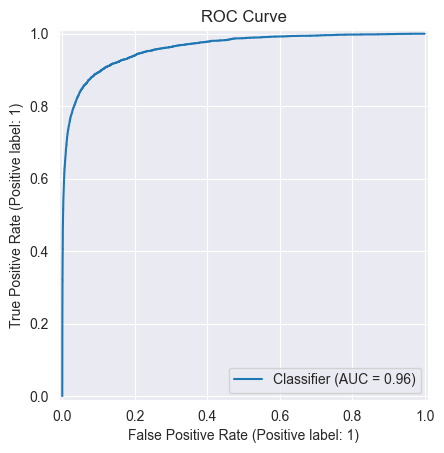

In [23]:

roc_auc = roc_auc_score(y_val, y_proba)
f1 = f1_score(y_val, y_pred)
print("Test ROC AUC:", roc_auc)+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
print("Test f1:", f1)

print("Classification Report:")
print(classification_report(y_val, y_pred))

conf_matrix = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

RocCurveDisplay.from_predictions(y_val, y_proba)
plt.title("ROC Curve")
plt.show()

In [16]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 1.0, 0.01)
best_f1 = 0
best_threshold = 0.5  # Default threshold

for threshold in thresholds:
    y_pred_new = (y_pred_proba >= threshold).astype(int)  # Apply threshold
    current_f1 = f1_score(y, y_pred_new)  # Compute F1
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(f"Optimal Threshold: {best_threshold:.2f}, Max F1: {best_f1:.4f}")

Optimal Threshold: 0.43, Max F1: 0.5596
